In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calplot
import json
import plotly.express as px

# Complaints

## 1. Dataset overview

In [ ]:
df_complaints=pd.read_csv("data/complaints20_25_original.csv")
print(df_complaints.isna().sum())
df_complaints = df_complaints.drop(columns=["agency_name"])
df_complaints.head()

unique_key          0
created_date        0
agency_name         0
complaint_type      0
incident_zip        0
council_district    0
borough             0
dtype: int64


,unique_key,created_date,complaint_type,incident_zip,council_district,borough
0,67350845,2025-12-31 23:57:56,HEAT/HOT WATER,11229,46,BROOKLYN
1,67347338,2025-12-31 23:54:46,HEAT/HOT WATER,11239,42,BROOKLYN
2,67350847,2025-12-31 23:54:42,HEAT/HOT WATER,10040,10,MANHATTAN
3,67346000,2025-12-31 23:54:41,HEAT/HOT WATER,10463,10,MANHATTAN
4,67349568,2025-12-31 23:54:14,HEAT/HOT WATER,10454,8,BRONX


In [ ]:
print(f"Number of complaints: {len(df_complaints)}")

df_complaints["created_date"]=pd.to_datetime(df_complaints["created_date"]) #add smth for errors
print(f"Date range: {df_complaints["created_date"].min()}, {df_complaints["created_date"].max()}")

unique_comp=list(df_complaints["complaint_type"].unique())
print(f"Number of types of complaints: {len(unique_comp)}")
print(f"Types of compaints: {unique_comp}")

print(f"Number of different zipcodes: {len(df_complaints["incident_zip"].unique())}")
print(f"Number of different council districts: {len(df_complaints["council_district"].unique())}")
print(f"Number of different boroughs: {len(df_complaints["borough"].unique())}")

Number of complaints: 2468050
Date range: 2021-01-01 00:01:14, 2025-12-31 23:57:56
Number of types of complaints: 5
Types of compaints: ['HEAT/HOT WATER', 'PLUMBING', 'WATER LEAK', 'UNSANITARY CONDITION', 'ELECTRIC']
Number of different zipcodes: 211
Number of different council districts: 51
Number of different boroughs: 5


In [ ]:
print(f"Number of complaints per type:\n {df_complaints["complaint_type"].value_counts()}")

comp_borough=df_complaints["borough"].value_counts()
print(f"\nNumber of complaints per borough:\n {comp_borough}")

comp_zip=df_complaints["incident_zip"].value_counts()
print(f"\nTop 5 Number of complaints per zip code:\n {comp_zip.head(5)}")

Number of complaints per type:
 complaint_type
HEAT/HOT WATER          1275874
UNSANITARY CONDITION     544853
PLUMBING                 307724
WATER LEAK               201971
ELECTRIC                 137628
Name: count, dtype: int64

Number of complaints per borough:
 borough
BRONX            860262
BROOKLYN         704758
MANHATTAN        535965
QUEENS           325246
STATEN ISLAND     41819
Name: count, dtype: int64

Top 5 Number of complaints per zip code:
 incident_zip
11226    79734
10452    75280
10457    73393
10458    72942
10467    72182
Name: count, dtype: int64


The number of complaints per borough might be influenced by how many people live there. Lets take that into account and calculate the number of complaints per 1000 people in each borough.

In [ ]:
borough_order = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
comp_borough = df_complaints["borough"].value_counts().reindex(borough_order)
borough_pop = pd.Series([1446788, 2648452, 1638281, 2330295, 487155],index=borough_order)
complaints_per_1000 = (comp_borough / borough_pop) * 1000
df_rates = pd.DataFrame({
    "complaints": comp_borough,
    "population": borough_pop,
    "complaints_per_1000": complaints_per_1000
})
df_rates

,complaints,population,complaints_per_1000
BRONX,860262,1446788,594.601282
BROOKLYN,704758,2648452,266.101859
MANHATTAN,535965,1638281,327.150837
QUEENS,325246,2330295,139.572887
STATEN ISLAND,41819,487155,85.843315


Number of complaints per zip code on map also by complaints per 1000 in each zipcode

https://www.newyork-demographics.com/zip_codes_by_population

In [ ]:
zip_pop = pd.read_csv("data/nyc_demographics/zipcode_populations.csv")
zip_pop["Population"] = zip_pop["Population"].str.replace(",", "").astype(int)
zip_pop.head()

,Zip Code,Population
0,11368,105716
1,11208,105428
2,11385,101704
3,11373,98403
4,10467,96421


In [ ]:
comp_zip_df = comp_zip.rename_axis("Zip Code").reset_index(name="complaints")
comp_zip_pop = comp_zip_df.merge(zip_pop, on="Zip Code", how="left")
comp_zip_pop.head()

,Zip Code,complaints,Population
0,11226,79734,95144.0
1,10452,75280,75682.0
2,10457,73393,79543.0
3,10458,72942,74898.0
4,10467,72182,96421.0


In [ ]:
comp_zip_pop["complaints_1000"]=(comp_zip_pop["complaints"]/comp_zip_pop["Population"])*1000

Zip codes with nan values appear grey, no color

In [ ]:
min_range=comp_zip_pop["complaints_1000"].min()
max_range=comp_zip_pop["complaints_1000"].max()

In [ ]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    comp_zip_pop,
    geojson=zip_geo,
    locations="Zip Code",
    color="complaints_1000",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "Zip Code": True,
        "complaints_1000": True
    },
    labels={
        "complaints_1000": "Complaints",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Complaints per 1000 residents")

fig.write_html("data/visualizations/zip_complaints_map.html")

C:\Users\Maria\AppData\Local\Temp\ipykernel_24620\330332475.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


## 2. Yearly trends per type and borough

In [ ]:
df_complaints["year"]=df_complaints["created_date"].dt.year
year_type = df_complaints.groupby(["year", "complaint_type"]).size().unstack(fill_value=0)
year_type

complaint_type,ELECTRIC,HEAT/HOT WATER,PLUMBING,UNSANITARY CONDITION,WATER LEAK
year,,,,,
2021,23547,199547,51903,90369,36549
2022,26971,264380,57544,99240,35676
2023,28402,231308,62860,116686,46188
2024,28123,264719,65884,120837,45166
2025,30585,315920,69533,117721,38392


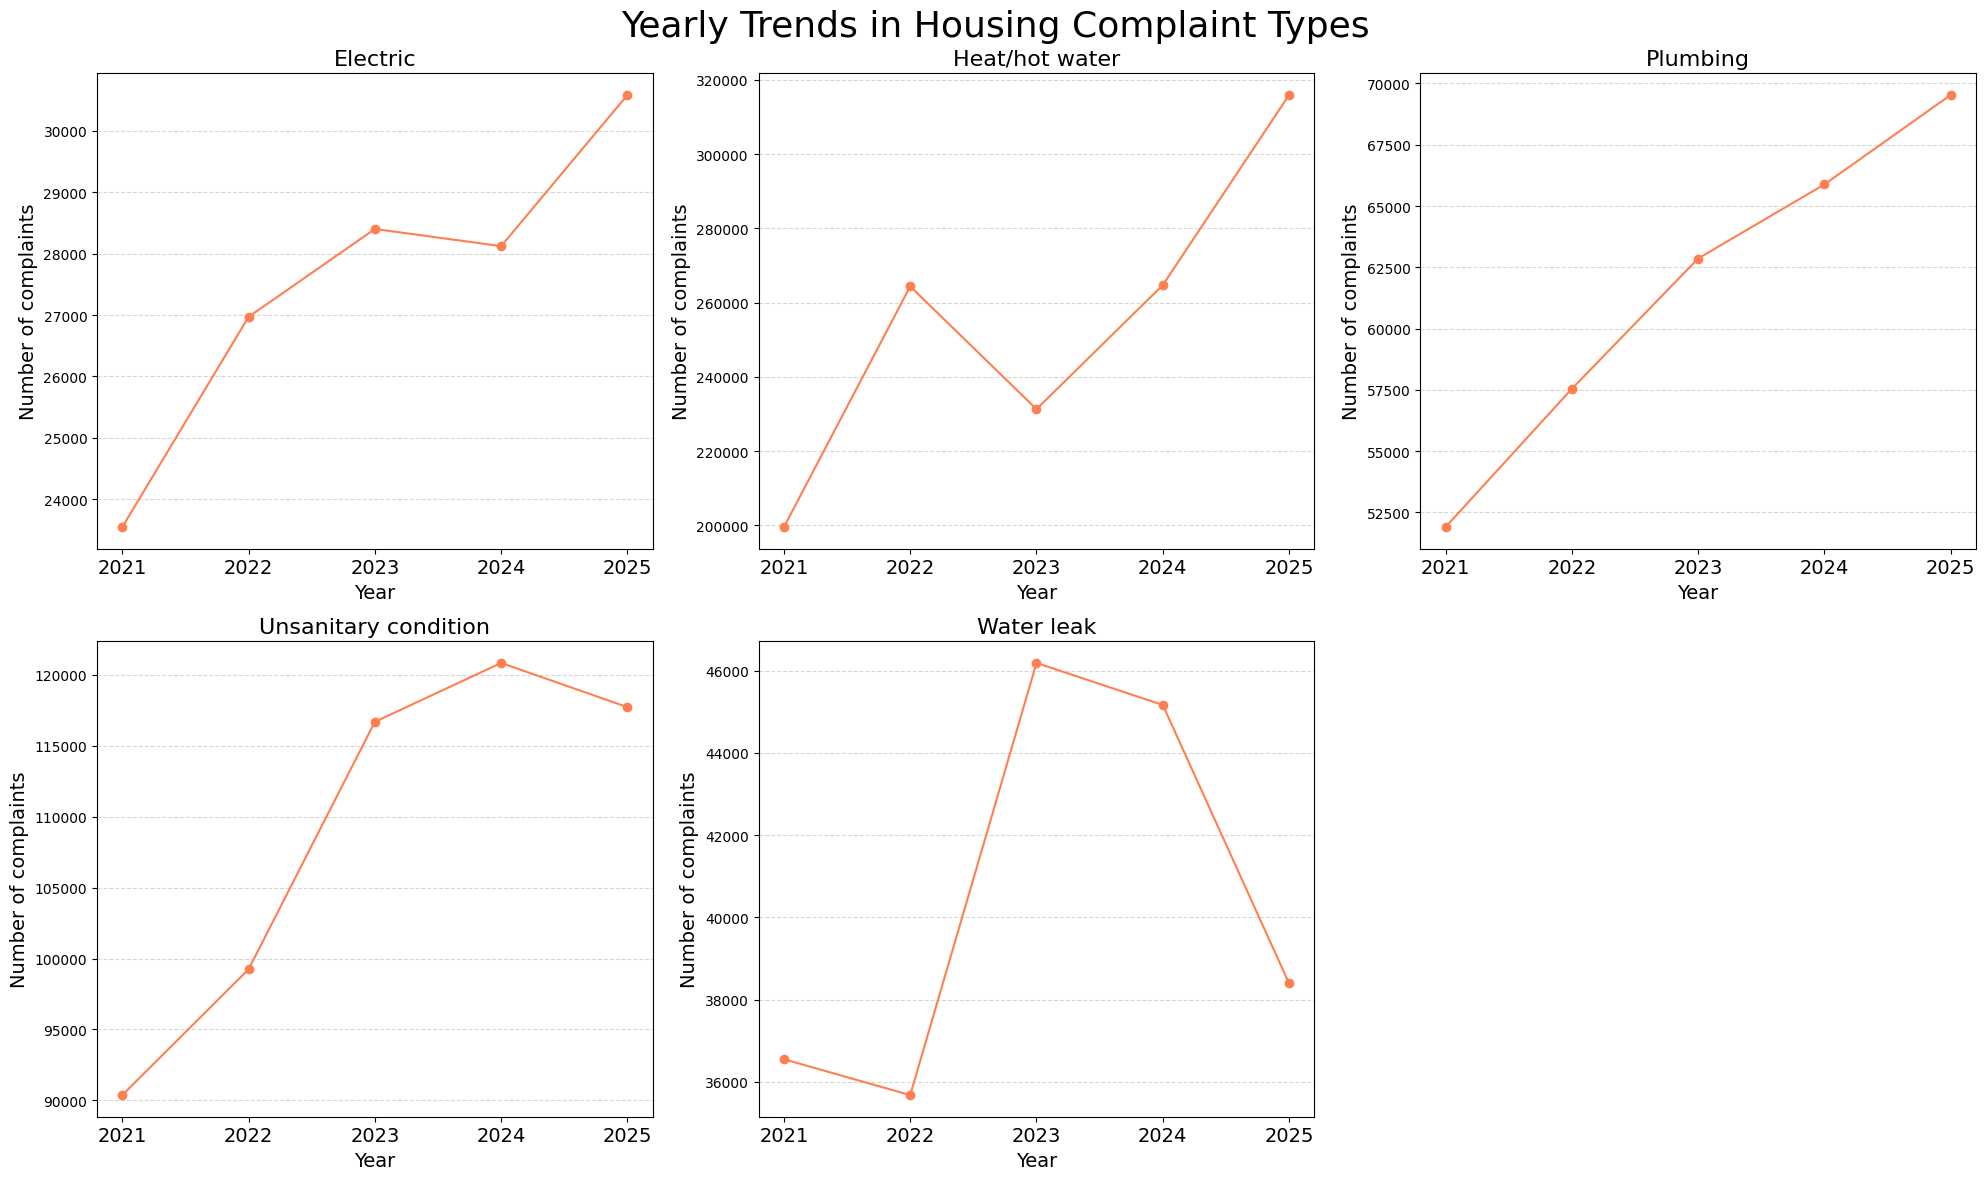

In [ ]:
comp_types = year_type.columns.tolist()
years = sorted(year_type.index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, cat in enumerate(comp_types):
    values = year_type[cat].values
    axes[i].plot(years, values, color="coral", marker='o')
    axes[i].set_title(cat.capitalize(), fontsize=16)
    axes[i].set_xlabel("Year", fontsize=14)
    axes[i].set_xticks(years)
    axes[i].set_xticklabels(years, fontsize=14)
    axes[i].set_ylabel("Number of complaints", fontsize=14)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Remove the unused subplot
for j in range(len(comp_types), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Yearly Trends in Housing Complaint Types", fontsize=26)
plt.tight_layout()
plt.show()


In [ ]:
year_boro = df_complaints.groupby(["year", "borough"]).size().unstack(fill_value=0)
print(year_boro)
year_boro_norm = year_boro.div(borough_pop, axis=1) * 1000
print(year_boro_norm)

borough   BRONX  BROOKLYN  MANHATTAN  QUEENS  STATEN ISLAND
year                                                       
2021     138143    119800      85022   51747           7203
2022     170131    139217     102777   63158           8528
2023     168318    138601     105276   63823           9426
2024     184587    147865     111768   72283           8226
2025     199083    159275     131122   74235           8436
borough       BRONX   BROOKLYN  MANHATTAN     QUEENS  STATEN ISLAND
year                                                               
2021      95.482545  45.233971  51.897080  22.206201      14.785848
2022     117.592211  52.565423  62.734659  27.103006      17.505722
2023     116.339090  52.332834  64.260038  27.388378      19.349078
2024     127.584000  55.830727  68.222729  31.018820      16.885796
2025     137.603436  60.138904  80.036331  31.856482      17.316870


In [ ]:
boroughs = year_boro.columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, borough in enumerate(boroughs):
    axes[i].plot(
        year_boro_norm.index,
        year_boro_norm[borough],
        marker='o',
        color='coral'
    )
    axes[i].set_title(borough.capitalize(), fontsize=16)
    axes[i].set_xlabel("Year", fontsize=14)
    axes[i].set_xticks(years)
    axes[i].set_xticklabels(years, fontsize=14)
    axes[i].set_ylabel("Number of complaints", fontsize=14)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Remove the unused subplot
for j in range(len(boroughs), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Population‑Normalized Housing Complaint Rates by Borough", fontsize=26)
plt.tight_layout()
plt.show()


NameError: name 'year_boro' is not defined

In [39]:
grouped = (df_complaints.groupby(["borough", "year", "complaint_type"]).size().reset_index(name="count"))

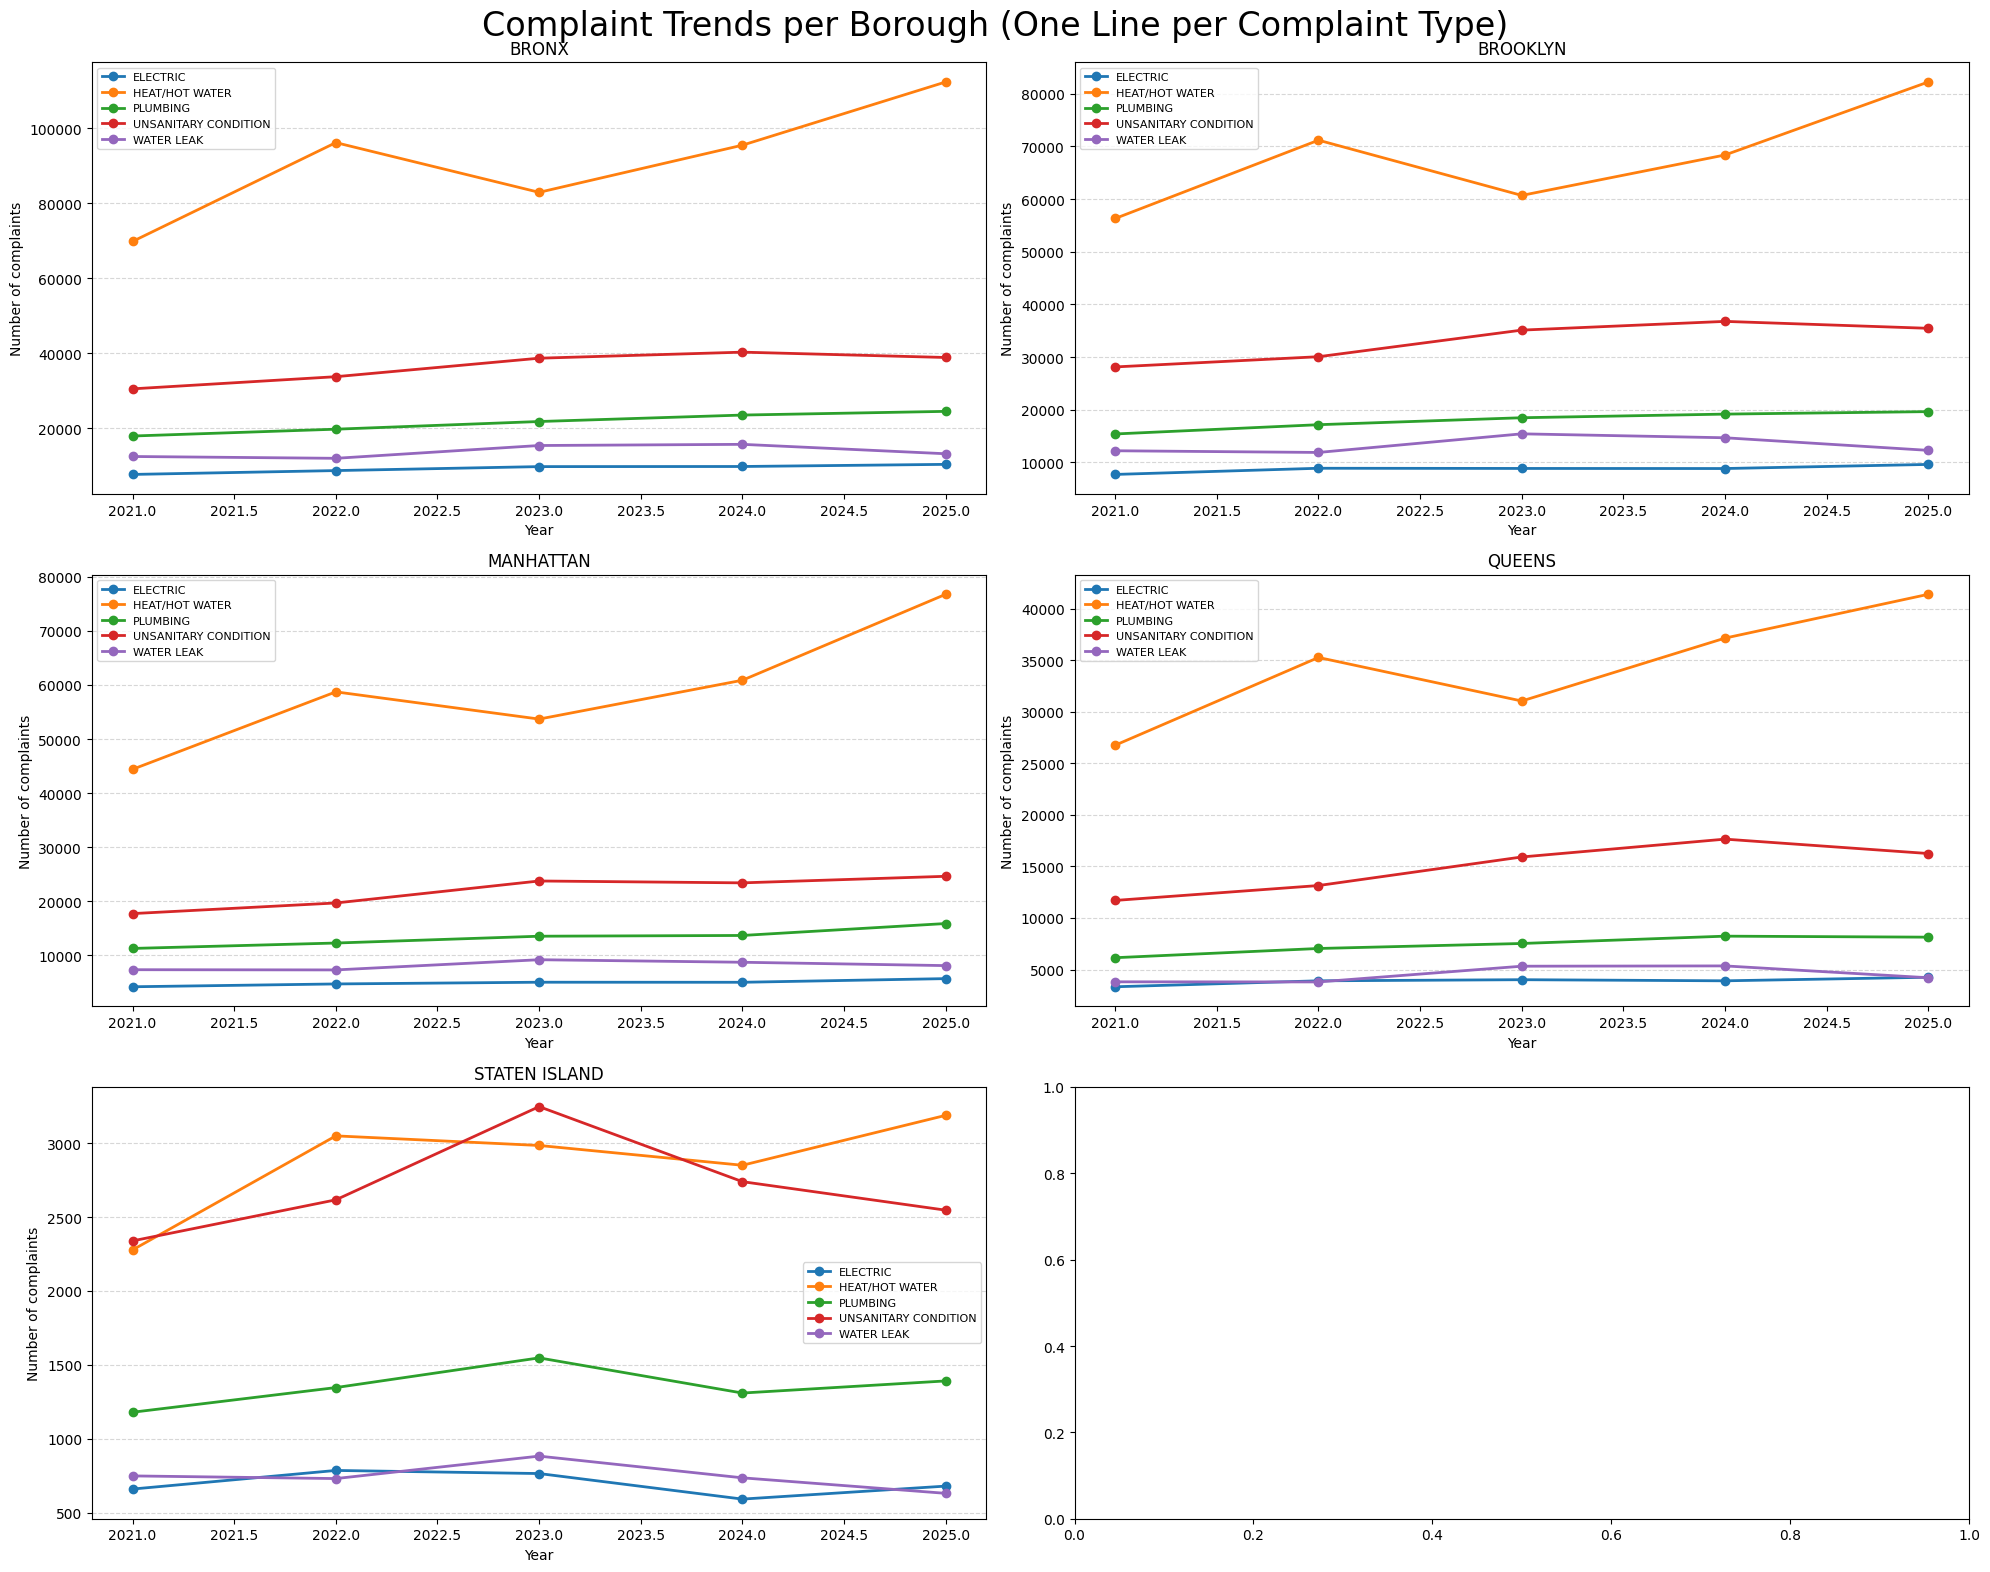

In [40]:
boroughs = grouped["borough"].unique()

fig, axes = plt.subplots(3, 2, figsize=(20, 16))
axes = axes.flatten()

for i, borough in enumerate(boroughs):
    df_b = grouped[grouped["borough"] == borough]

    for comp_type in df_b["complaint_type"].unique():
        df_t = df_b[df_b["complaint_type"] == comp_type]

        axes[i].plot(
            df_t["year"],
            df_t["count"],
            marker='o',
            linewidth=2,
            label=comp_type
        )

    axes[i].set_title(borough)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Number of complaints")
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i].legend(fontsize=8)

plt.suptitle("Complaint Trends per Borough (One Line per Complaint Type)", fontsize=24)
plt.tight_layout()
plt.show()


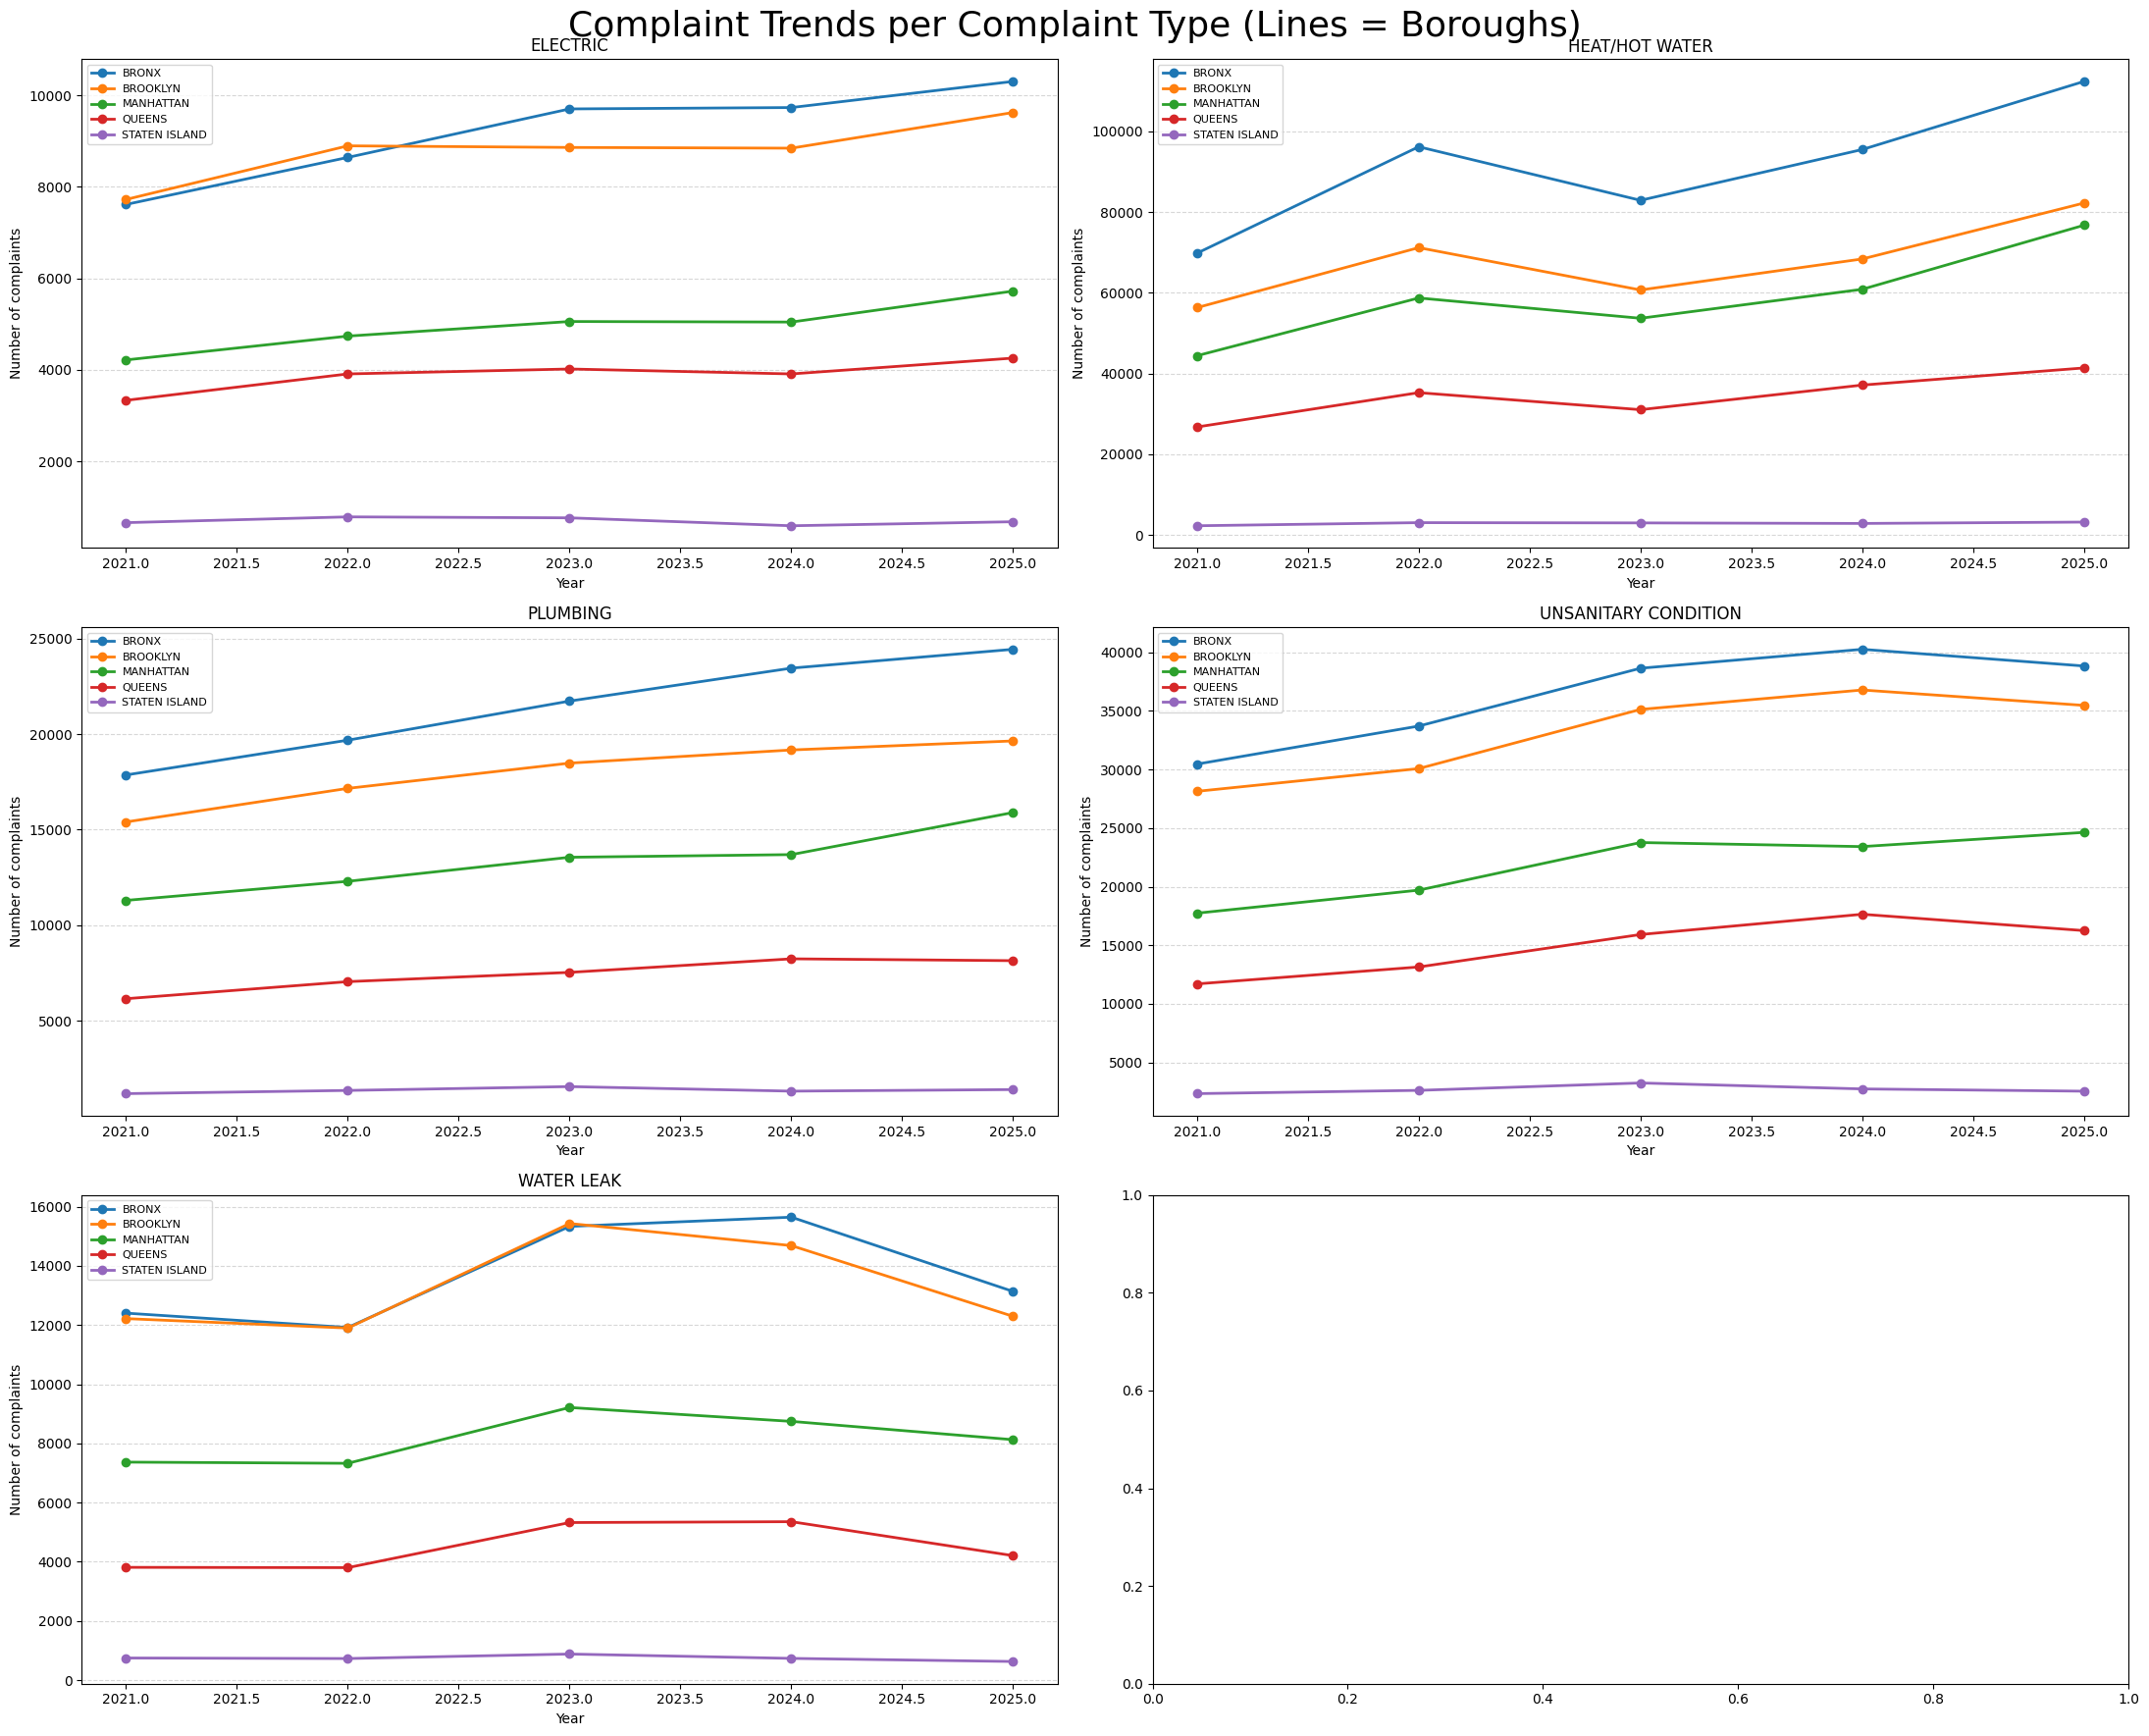

In [41]:
complaints = grouped["complaint_type"].unique()

fig, axes = plt.subplots(3, 2, figsize=(22, 18))  # adjust grid if needed
axes = axes.flatten()

for i, comp in enumerate(complaints):
    df_c = grouped[grouped["complaint_type"] == comp]

    for borough in df_c["borough"].unique():
        df_b = df_c[df_c["borough"] == borough]

        axes[i].plot(
            df_b["year"],
            df_b["count"],
            marker='o',
            linewidth=2,
            label=borough
        )

    axes[i].set_title(comp)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Number of complaints")
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i].legend(fontsize=8)

plt.suptitle("Complaint Trends per Complaint Type (Lines = Boroughs)", fontsize=26)
plt.tight_layout()
plt.show()


## 3. Proportionality of trend types across boroughs

Probability of complaint type in whole dataset

In [42]:
p_type=df_complaints["complaint_type"].value_counts(normalize=True)
p_type

complaint_type
HEAT/HOT WATER          0.516956
UNSANITARY CONDITION    0.220763
PLUMBING                0.124683
WATER LEAK              0.081834
ELECTRIC                0.055764
Name: proportion, dtype: float64

Probability of complaint type in district

In [43]:
p_type_boro=(df_complaints.groupby("borough")["complaint_type"].value_counts(normalize=True))
p_type_boro = p_type_boro.unstack()
p_type_boro

complaint_type,ELECTRIC,HEAT/HOT WATER,PLUMBING,UNSANITARY CONDITION,WATER LEAK
borough,,,,,
BRONX,0.053470,0.530937,0.124621,0.211419,0.079553
BROOKLYN,0.062363,0.480751,0.127544,0.234944,0.094397
MANHATTAN,0.046223,0.549303,0.124547,0.203838,0.076089
QUEENS,0.059730,0.527465,0.114080,0.229540,0.069185
STATEN ISLAND,0.083168,0.343217,0.161936,0.322605,0.089074


In [44]:
ratio = p_type_boro.div(p_type, axis=1)

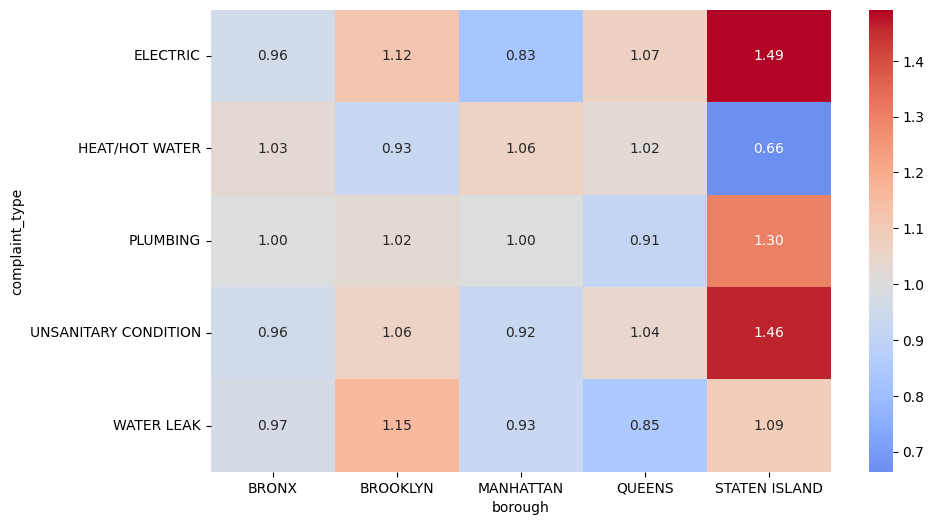

In [45]:
plt.figure(figsize=(10,6))
sns.heatmap(ratio.T, cmap="coolwarm", center=1, annot=True, fmt=".2f")
plt.show()

In [46]:
df_complaints.head()

,unique_key,created_date,complaint_type,incident_zip,council_district,borough,year
0,67350845,2025-12-31 23:57:56,HEAT/HOT WATER,11229,46,BROOKLYN,2025
1,67347338,2025-12-31 23:54:46,HEAT/HOT WATER,11239,42,BROOKLYN,2025
2,67350847,2025-12-31 23:54:42,HEAT/HOT WATER,10040,10,MANHATTAN,2025
3,67346000,2025-12-31 23:54:41,HEAT/HOT WATER,10463,10,MANHATTAN,2025
4,67349568,2025-12-31 23:54:14,HEAT/HOT WATER,10454,8,BRONX,2025


## 4. Calendar plot

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


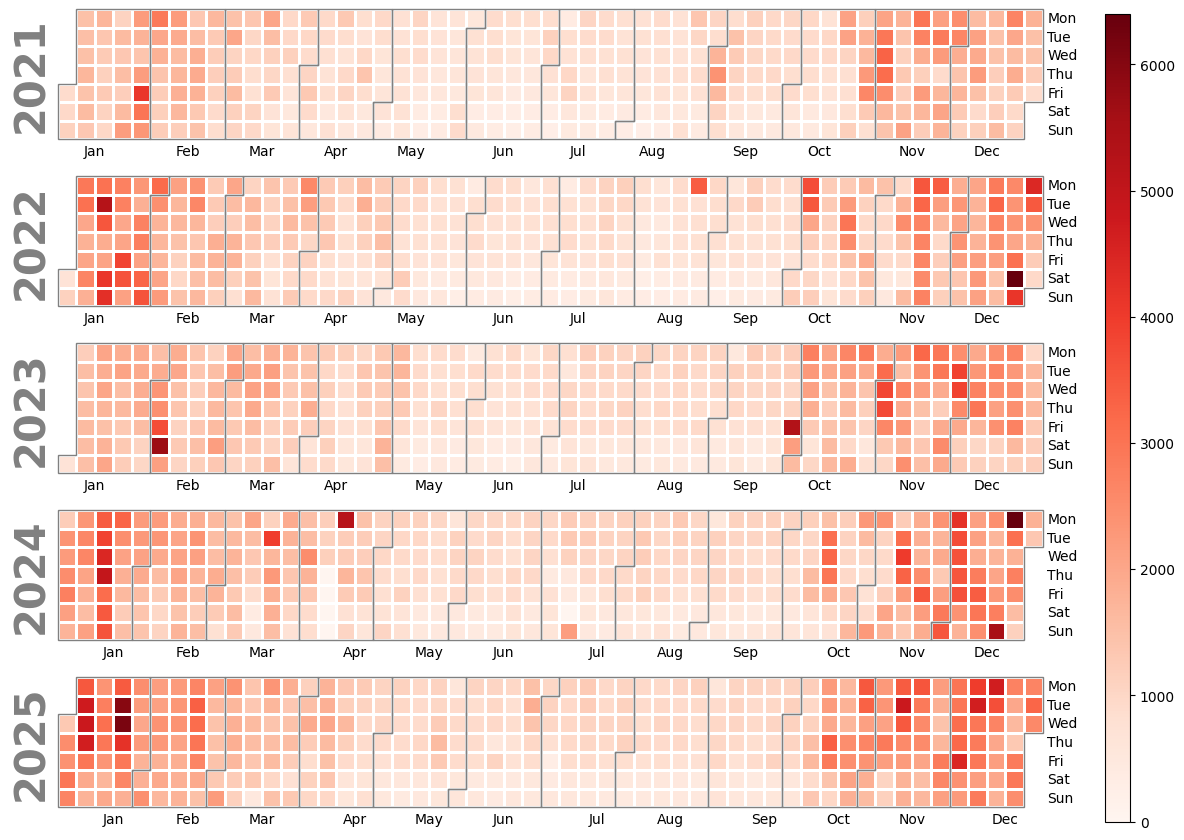

In [47]:
df_complaints["date"] = df_complaints["created_date"].dt.floor("D")
daily_counts = df_complaints.groupby("date").size()
calplot.calplot(daily_counts, cmap='Reds')
plt.show()

# Violations

## 1. Dataset Overview

Next steps:
- inspecdate - certifdate (ver se é maior oara lower income)
- 

In [68]:
df_violations=pd.read_csv("data/violations20_25_original.csv")
print(df_violations.isna().sum())
df_violations.head()

violationid                    0
zip                         4370
class                          0
inspectiondate                 0
originalcorrectbydate        748
boro                           0
certifieddate            2319878
newcorrectbydate         3966409
dtype: int64


,violationid,zip,class,inspectiondate,originalcorrectbydate,boro,certifieddate,newcorrectbydate
0,18563058,10460.0,B,2025-12-31,2026-03-09T00:00:00.000,BRONX,2026-03-12T00:00:00.000,NaN
1,18542042,11232.0,C,2025-12-31,2026-01-01T00:00:00.000,BROOKLYN,2026-01-05T00:00:00.000,NaN
2,18542397,10459.0,B,2025-12-31,2026-02-06T00:00:00.000,BRONX,2026-02-04T00:00:00.000,NaN
3,18542363,11234.0,C,2025-12-31,2026-01-19T00:00:00.000,BROOKLYN,2026-01-21T00:00:00.000,NaN
4,18542254,11237.0,B,2025-12-31,2026-02-09T00:00:00.000,BROOKLYN,2026-03-02T00:00:00.000,NaN


In [ ]:
df_violations = df_violations.dropna(subset=["zip"])
df_violations["zip"] = df_violations["zip"].astype(int)
df_violations["zip"] = df_violations["zip"].astype(str)
df_violations = df_violations[df_violations["zip"].str.len() == 5]
df_violations["zip"] = df_violations["zip"].astype(int)

In [70]:
print(f"Number of violations: {len(df_violations)}")

df_violations["inspectiondate"]=pd.to_datetime(df_violations["inspectiondate"]) #add smth for errors
print(f"Date range: {df_violations["inspectiondate"].min()}, {df_violations["inspectiondate"].max()}")

viol_class=list(df_violations["class"].unique())
print(f"Number of classes of violations: {len(viol_class)}")
print(f"Classes of violations: {viol_class}")

print(f"Number of different zipcodes: {len(df_violations["zip"].unique())}")
print(f"Number of different boroughs: {len(df_violations["boro"].unique())}")

Number of violations: 3992008
Date range: 2021-01-03 00:00:00, 2025-12-31 00:00:00
Number of classes of violations: 3
Classes of violations: ['B', 'C', 'A']
Number of different zipcodes: 189
Number of different boroughs: 5


In [71]:
print(f"Number of violations per class:\n {df_violations["class"].value_counts()}")

viol_borough=df_violations["boro"].value_counts()
print(f"\nNumber of violations per borough:\n {viol_borough}")

viol_zip=df_violations["zip"].value_counts()
print(f"\nTop 5 Number of violations per zip code:\n {viol_zip.head(5)}")

Number of violations per class:
 class
B    1651328
C    1203244
A    1137436
Name: count, dtype: int64

Number of violations per borough:
 boro
BROOKLYN         1393049
BRONX            1339718
MANHATTAN         704949
QUEENS            494617
STATEN ISLAND      59675
Name: count, dtype: int64

Top 5 Number of violations per zip code:
 zip
11226    152100
10458    123244
10457    116675
10467    115073
10456    111025
Name: count, dtype: int64


Number of violations per borough has to be adjusted for the population

In [72]:
borough_order = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
viol_boro = df_violations["boro"].value_counts().reindex(borough_order)
borough_pop = pd.Series([1446788, 2648452, 1638281, 2330295, 487155],index=borough_order)
violations_per_1000 = (viol_boro / borough_pop) * 1000
df_boro = pd.DataFrame({
    "complaints": viol_boro,
    "population": borough_pop,
    "violations_per_1000": violations_per_1000
})
df_boro

,complaints,population,violations_per_1000
BRONX,1339718,1446788,925.994686
BROOKLYN,1393049,2648452,525.986123
MANHATTAN,704949,1638281,430.297977
QUEENS,494617,2330295,212.255101
STATEN ISLAND,59675,487155,122.496947


Number of violations per zip

In [73]:
zip_pop = pd.read_csv("data/nyc_demographics/zipcode_populations.csv")
zip_pop["Population"] = zip_pop["Population"].str.replace(",", "").astype(int)
zip_pop.head()

,Zip Code,Population
0,11368,105716
1,11208,105428
2,11385,101704
3,11373,98403
4,10467,96421


In [74]:
viol_zip_df = viol_zip.rename_axis("Zip Code").reset_index(name="violations")
viol_zip_pop = viol_zip_df.merge(zip_pop, on="Zip Code", how="left")
viol_zip_pop.head()

,Zip Code,violations,Population
0,11226,152100,95144.0
1,10458,123244,74898.0
2,10457,116675,79543.0
3,10467,115073,96421.0
4,10456,111025,87533.0


In [75]:
viol_zip_pop["violations_1000"]=(viol_zip_pop["violations"]/viol_zip_pop["Population"])*1000
viol_zip_pop

,Zip Code,violations,Population,violations_1000
0,11226,152100,95144.0,1598.629446
1,10458,123244,74898.0,1645.491201
2,10457,116675,79543.0,1466.816690
3,10467,115073,96421.0,1193.443337
4,10456,111025,87533.0,1268.378783
...,...,...,...,...
184,12238,3,NaN,NaN
185,10416,3,NaN,NaN
186,10105,2,NaN,NaN
187,10435,2,NaN,NaN


In [76]:
min_range=viol_zip_pop["violations_1000"].min()
max_range=viol_zip_pop["violations_1000"].max()

In [77]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    viol_zip_pop,
    geojson=zip_geo,
    locations="Zip Code",
    color="violations_1000",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "Zip Code": True,
        "violations_1000": True
    },
    labels={
        "violations_1000": "Complaints",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Violations per 1000 residents")

fig.write_html("data/visualizations/zip_violations_map.html")

C:\Users\Maria\AppData\Local\Temp\ipykernel_22564\3755128483.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


### Complaints per zip and per class

In [78]:
zip_class=df_violations.groupby(["zip", "class"]).size().unstack(fill_value=0)
zip_class = zip_class.reset_index()

zip_class_df = zip_class.merge(zip_pop, left_on="zip", right_on="Zip Code", how="left")
zip_class_df

,zip,A,B,C,Zip Code,Population
0,10001,1505,1516,1460,10001.0,30511.0
1,10002,5709,5975,5401,10002.0,76873.0
2,10003,5021,4243,4270,10003.0,53560.0
3,10004,89,50,68,10004.0,3711.0
4,10005,119,33,34,10005.0,9439.0
...,...,...,...,...,...,...
184,11691,7832,12396,8533,11691.0,69359.0
185,11692,3074,4233,3303,11692.0,22734.0
186,11693,780,643,465,11693.0,13244.0
187,11694,2384,1306,1139,11694.0,21489.0


In [79]:
df_A = zip_class_df.reset_index()[["zip", "A", "Population"]]
df_A["viol_1000"]=(df_A["A"]/df_A["Population"])*1000

min_range=df_A["viol_1000"].min()
max_range=df_A["viol_1000"].max()

df_A.head()

,zip,A,Population,viol_1000
0,10001,1505,30511.0,49.326472
1,10002,5709,76873.0,74.265347
2,10003,5021,53560.0,93.745332
3,10004,89,3711.0,23.982754
4,10005,119,9439.0,12.607268


In [80]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    df_A,
    geojson=zip_geo,
    locations="zip",
    color="viol_1000",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "viol_1000": True
    },
    labels={
        "violations_1000": "Complaints",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Violations per 1000 residents")

fig.write_html("data/visualizations/zip_violA_map.html")

C:\Users\Maria\AppData\Local\Temp\ipykernel_22564\2038220556.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


In [81]:
df_B = zip_class_df.reset_index()[["zip", "B", "Population"]]
df_B["viol_1000"]=(df_B["B"]/df_B["Population"])*1000

min_range=df_B["viol_1000"].min()
max_range=df_B["viol_1000"].max()

df_B.head()

,zip,B,Population,viol_1000
0,10001,1516,30511.0,49.686998
1,10002,5975,76873.0,77.725599
2,10003,4243,53560.0,79.219567
3,10004,50,3711.0,13.473457
4,10005,33,9439.0,3.496133


In [82]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    df_B,
    geojson=zip_geo,
    locations="zip",
    color="viol_1000",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "viol_1000": True
    },
    labels={
        "violations_1000": "Complaints",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Violations per 1000 residents")

fig.write_html("data/visualizations/zip_violB_map.html")

C:\Users\Maria\AppData\Local\Temp\ipykernel_22564\4222665543.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


In [83]:
df_C = zip_class_df.reset_index()[["zip", "C", "Population"]]
df_C["viol_1000"]=(df_C["C"]/df_C["Population"])*1000

min_range=df_C["viol_1000"].min()
max_range=df_C["viol_1000"].max()

df_C.head()

,zip,C,Population,viol_1000
0,10001,1460,30511.0,47.851595
1,10002,5401,76873.0,70.258738
2,10003,4270,53560.0,79.723674
3,10004,68,3711.0,18.323902
4,10005,34,9439.0,3.602076


In [84]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    df_C,
    geojson=zip_geo,
    locations="zip",
    color="viol_1000",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "viol_1000": True
    },
    labels={
        "violations_1000": "Complaints",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Violations per 1000 residents")

fig.write_html("data/visualizations/zip_violC_map.html")

C:\Users\Maria\AppData\Local\Temp\ipykernel_22564\1256672264.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


## 2. Yearly trends (inspectiondate)

In [44]:
df_violations["year"]=df_violations["inspectiondate"].dt.year
year_type_viol = df_violations.groupby(["year", "class"]).size().unstack(fill_value=0)
year_type_viol

class,A,B,C
year,,,
2021,240504,284568,176102
2022,229259,279150,202540
2023,225801,327664,249422
2024,234945,396141,297343
2025,206927,363805,277837


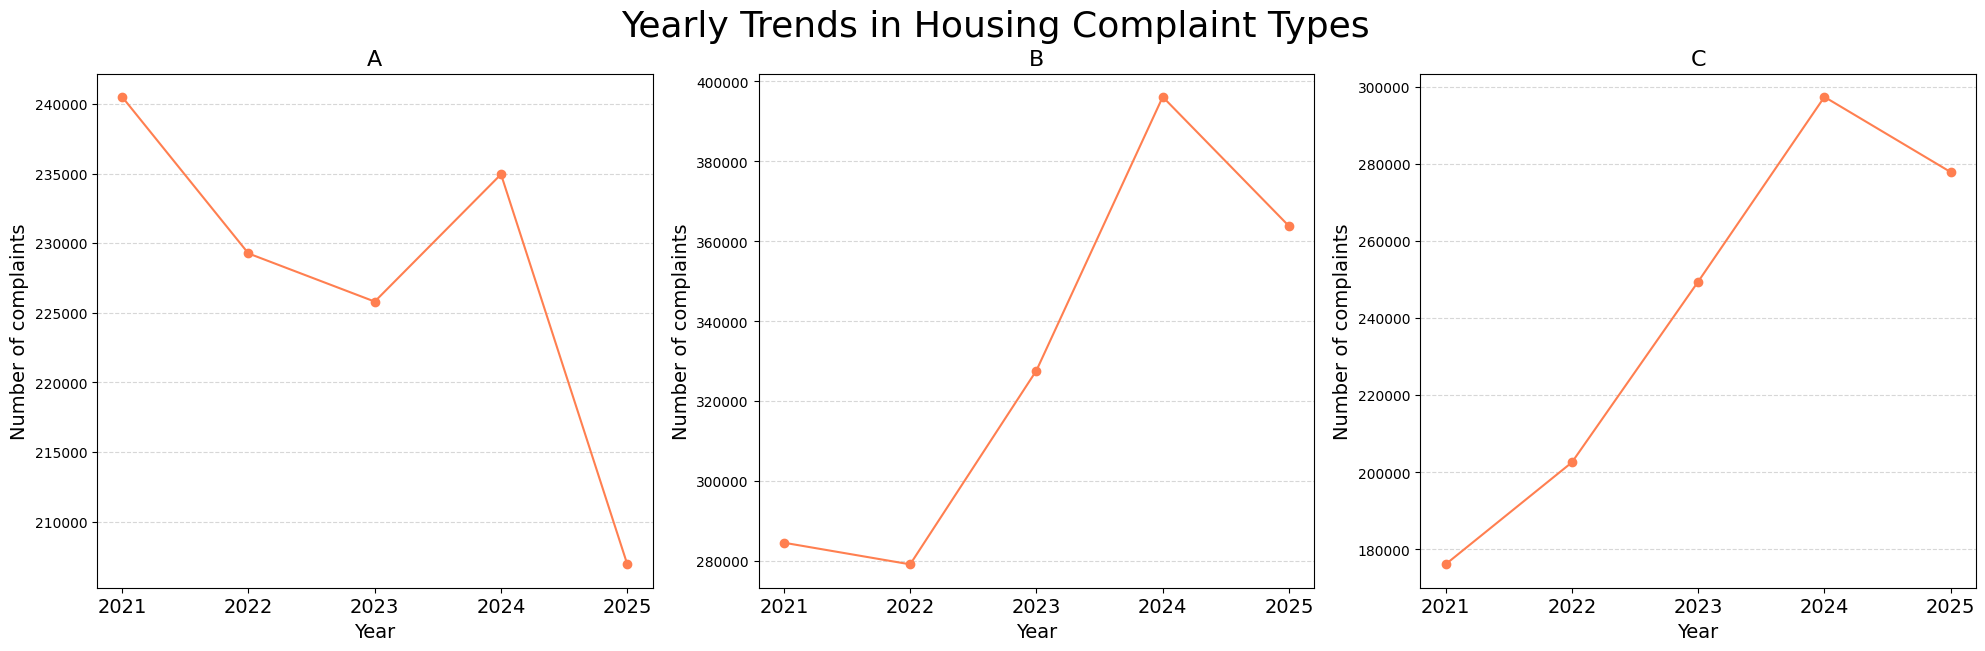

In [45]:
viol_types = year_type_viol.columns.tolist()
years = sorted(year_type_viol.index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, cat in enumerate(viol_types):
    values = year_type_viol[cat].values
    axes[i].plot(years, values, color="coral", marker='o')
    axes[i].set_title(cat.capitalize(), fontsize=16)
    axes[i].set_xlabel("Year", fontsize=14)
    axes[i].set_xticks(years)
    axes[i].set_xticklabels(years, fontsize=14)
    axes[i].set_ylabel("Number of complaints", fontsize=14)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Remove the unused subplot
for j in range(len(viol_types), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Yearly Trends in Housing Complaint Types", fontsize=26)
plt.tight_layout()
plt.show()

In [46]:
year_boro_viol = df_violations.groupby(["year", "boro"]).size().unstack(fill_value=0)
print(year_boro_viol)
year_boro_vnorm = year_boro_viol.div(borough_pop, axis=1) * 1000
print(year_boro_vnorm)

boro   BRONX  BROOKLYN  MANHATTAN  QUEENS  STATEN ISLAND
year                                                    
2021  201073    277083     135403   80112           7503
2022  218266    260945     133164   89216           9358
2023  261244    289176     145066   96480          10921
2024  349241    288309     150659  124190          16030
2025  309894    277536     140657  104619          15863
boro       BRONX    BROOKLYN  MANHATTAN     QUEENS  STATEN ISLAND
year                                                             
2021  138.978897  104.620737  82.649436  34.378480      15.401669
2022  150.862462   98.527366  81.282759  38.285281      19.209492
2023  180.568266  109.186800  88.547691  41.402483      22.417916
2024  241.390584  108.859439  91.961635  53.293682      32.905338
2025  214.194478  104.791780  85.856456  44.895174      32.562531


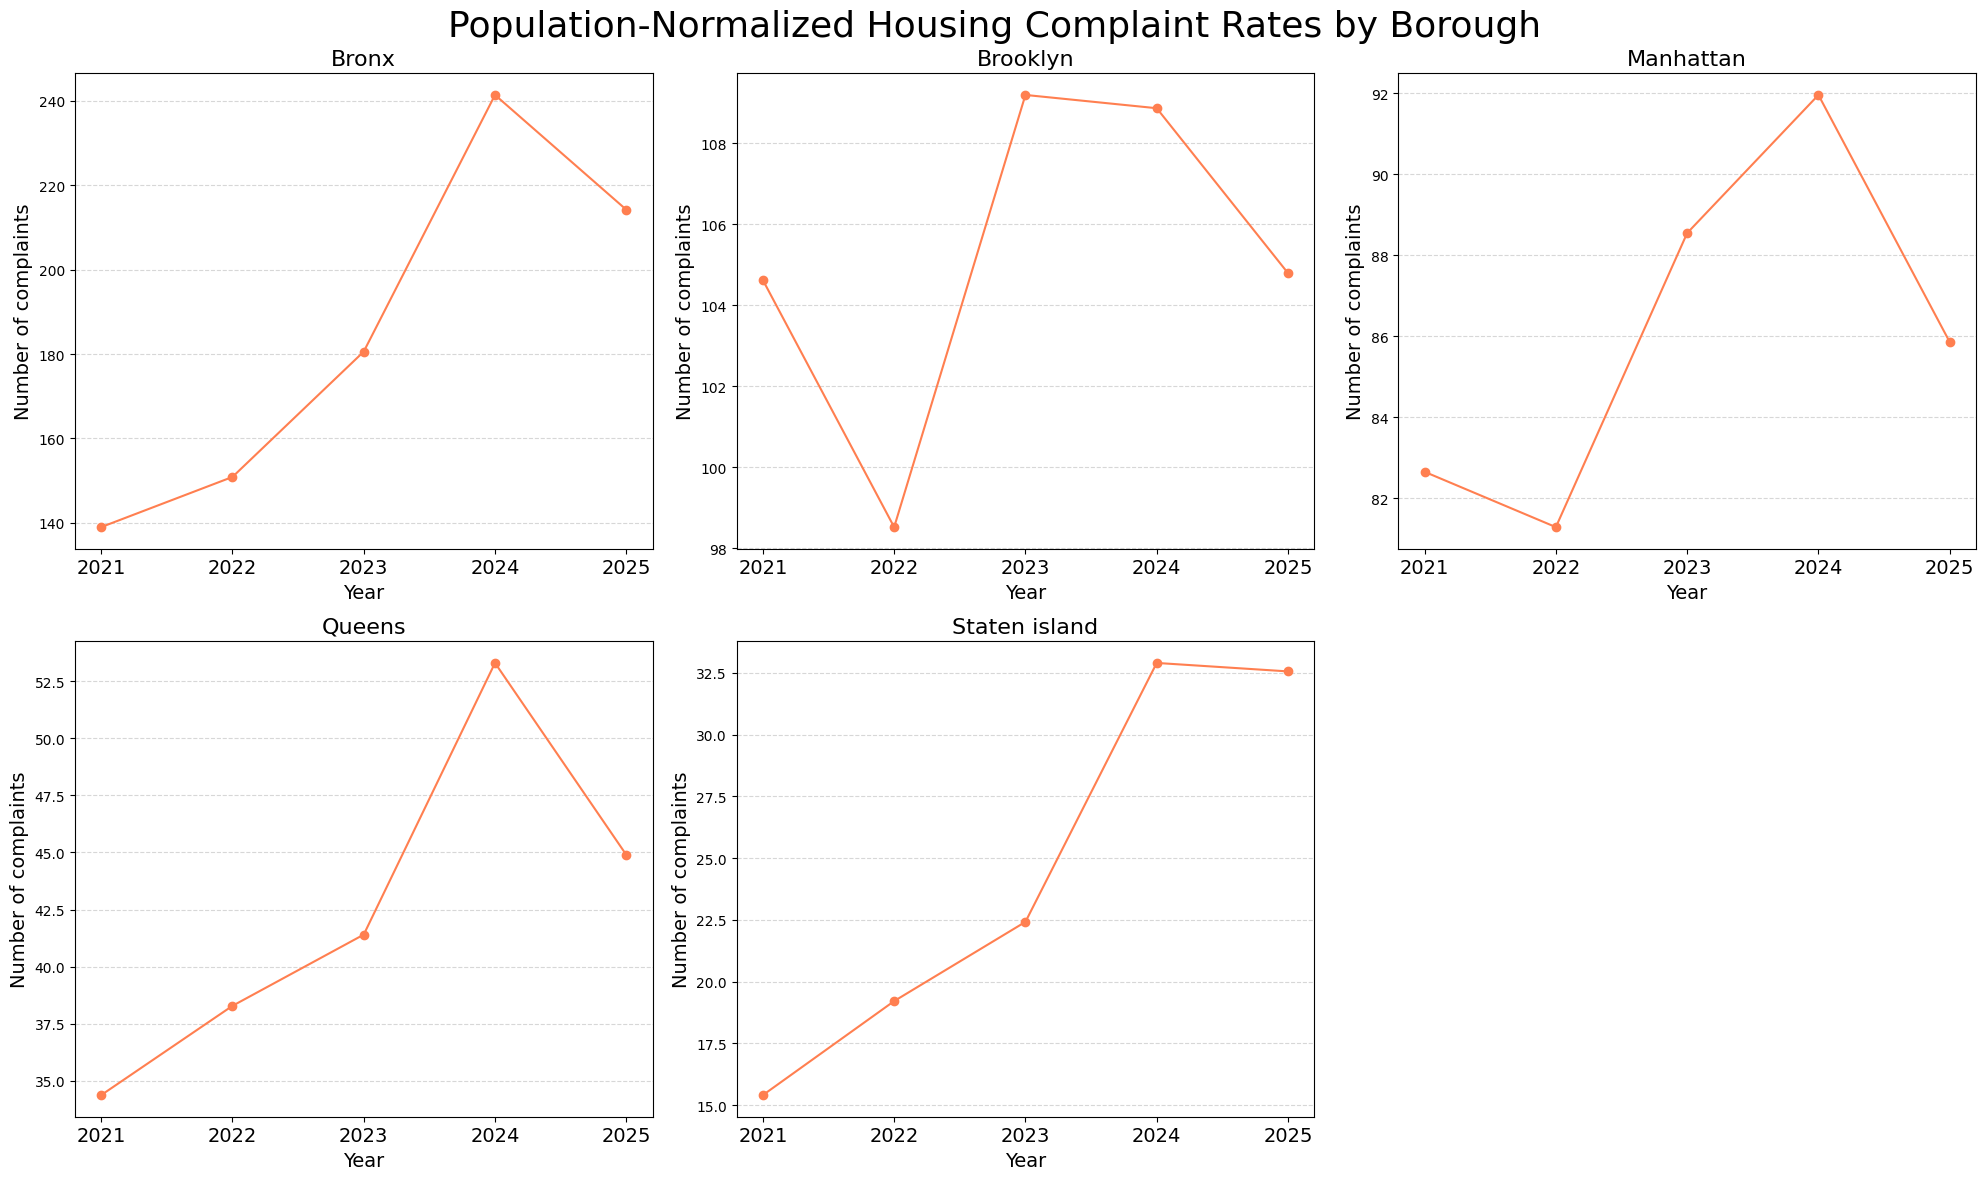

In [47]:
boroughs = year_boro_viol.columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, borough in enumerate(boroughs):
    axes[i].plot(
        year_boro_vnorm.index,
        year_boro_vnorm[borough],
        marker='o',
        color='coral'
    )
    axes[i].set_title(borough.capitalize(), fontsize=16)
    axes[i].set_xlabel("Year", fontsize=14)
    axes[i].set_xticks(years)
    axes[i].set_xticklabels(years, fontsize=14)
    axes[i].set_ylabel("Number of complaints", fontsize=14)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Remove the unused subplot
for j in range(len(boroughs), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Population‑Normalized Housing Complaint Rates by Borough", fontsize=26)
plt.tight_layout()
plt.show()

In [48]:
grouped_viol = (df_violations.groupby(["boro", "year", "class"]).size().reset_index(name="count"))

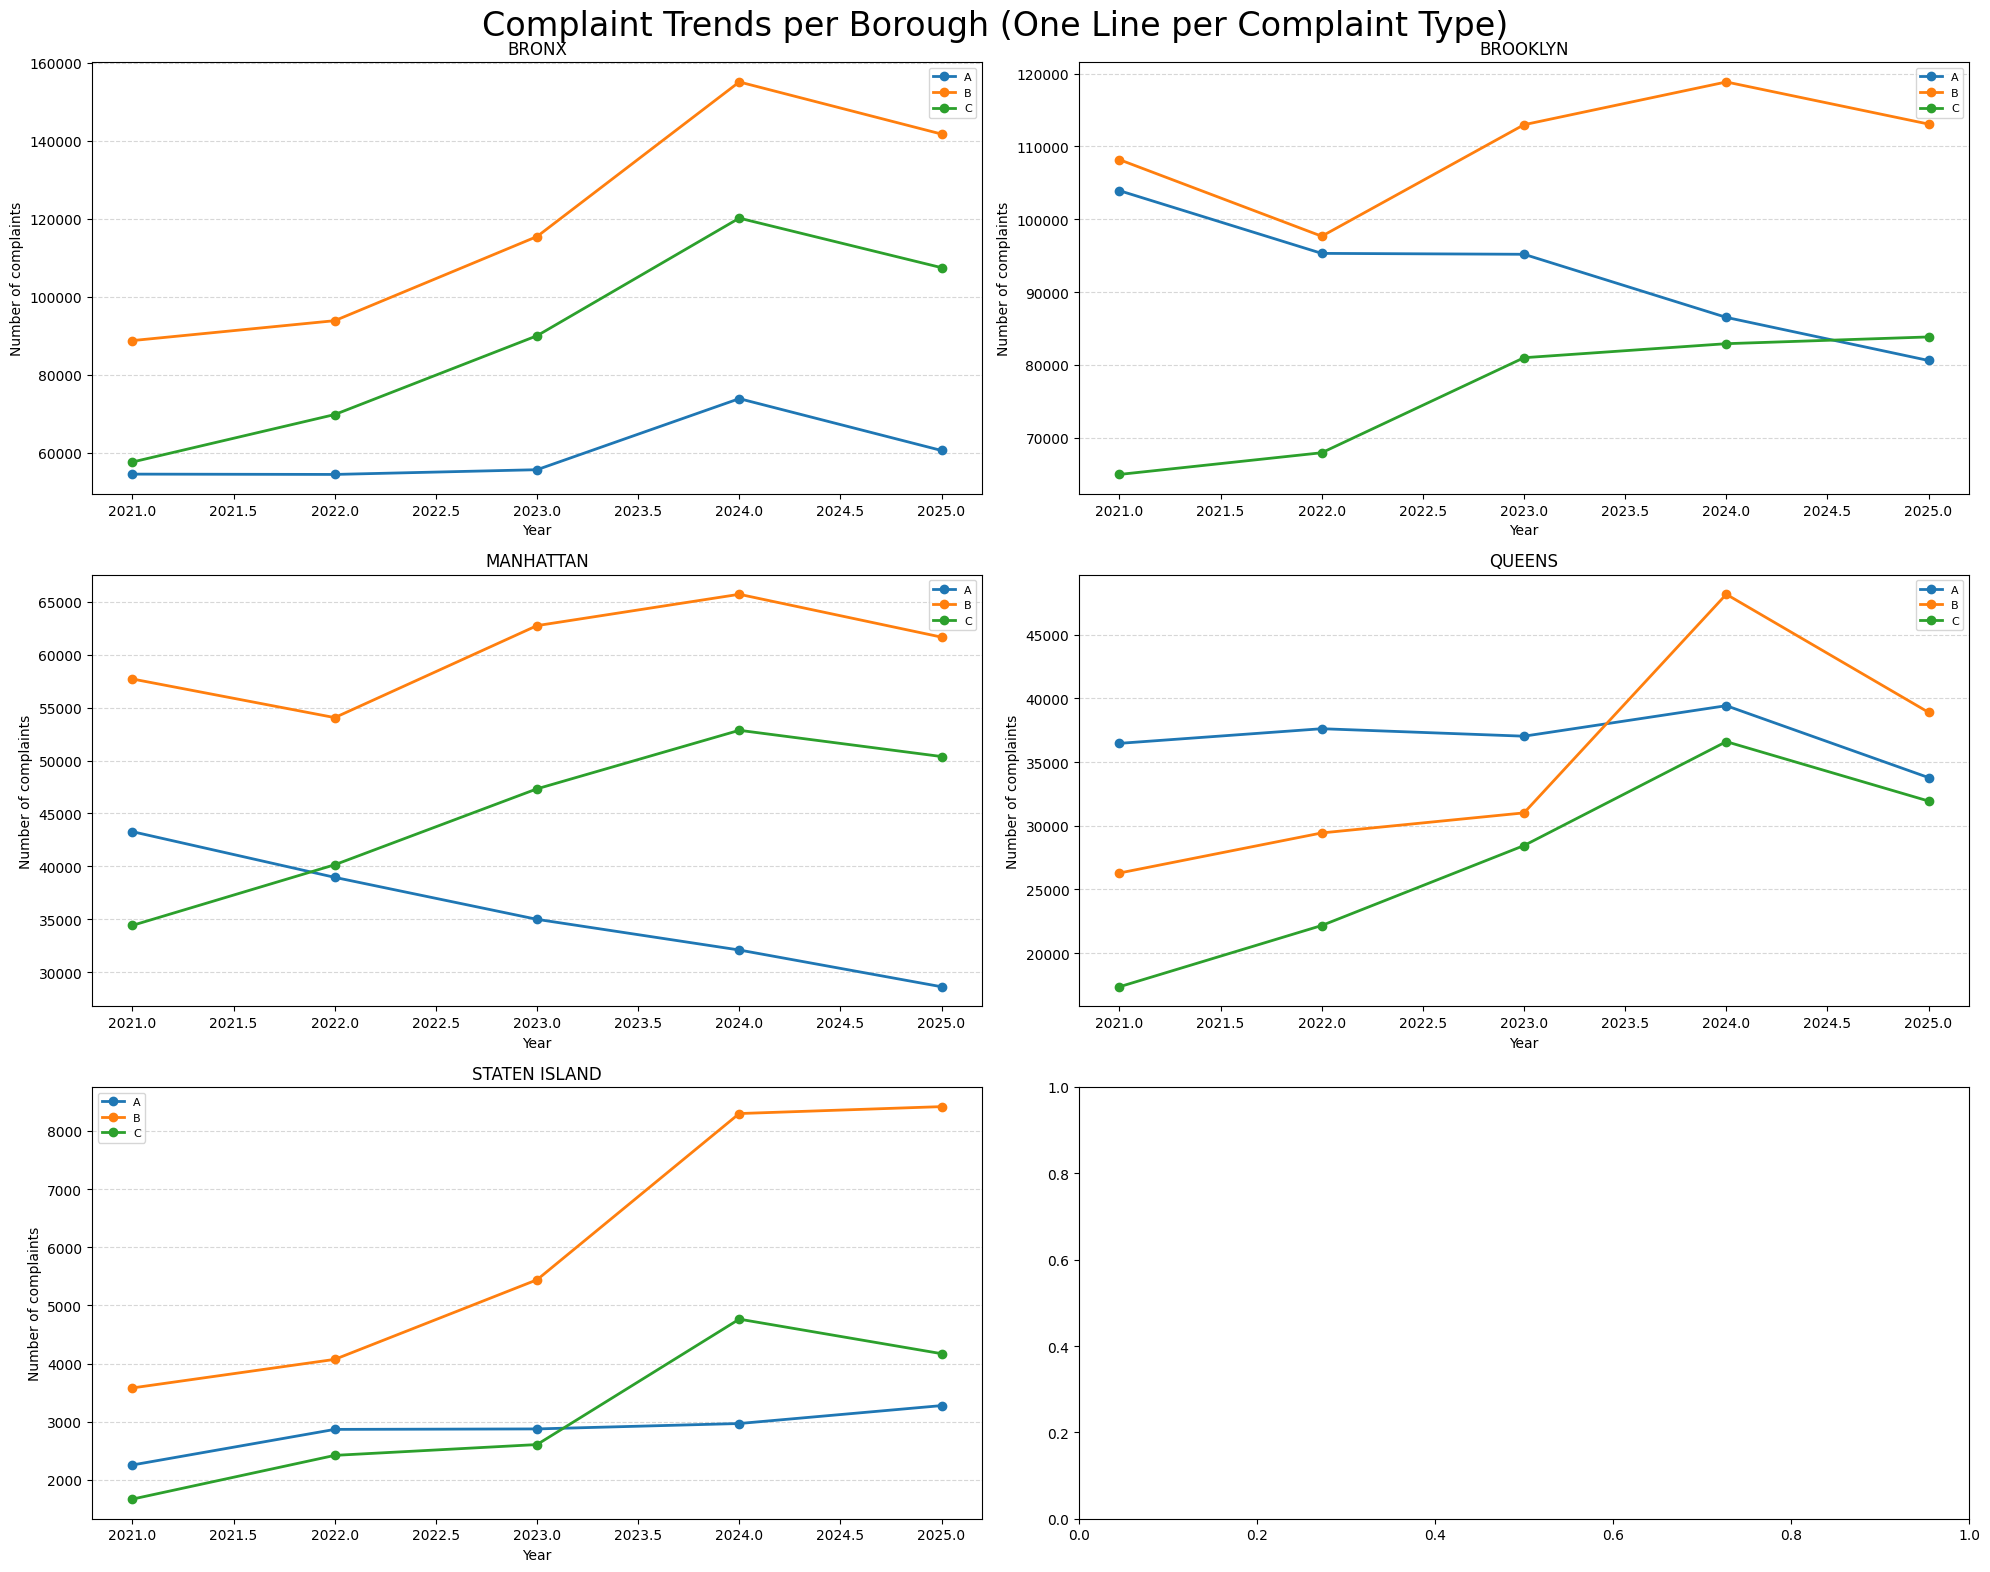

In [49]:
fig, axes = plt.subplots(3, 2, figsize=(20, 16))
axes = axes.flatten()

for i, borough in enumerate(boroughs):
    df_b = grouped_viol[grouped_viol["boro"] == borough]

    for viol_class in df_b["class"].unique():
        df_t = df_b[df_b["class"] == viol_class]

        axes[i].plot(
            df_t["year"],
            df_t["count"],
            marker='o',
            linewidth=2,
            label=viol_class
        )

    axes[i].set_title(borough)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Number of complaints")
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i].legend(fontsize=8)

plt.suptitle("Complaint Trends per Borough (One Line per Complaint Type)", fontsize=24)
plt.tight_layout()
plt.show()

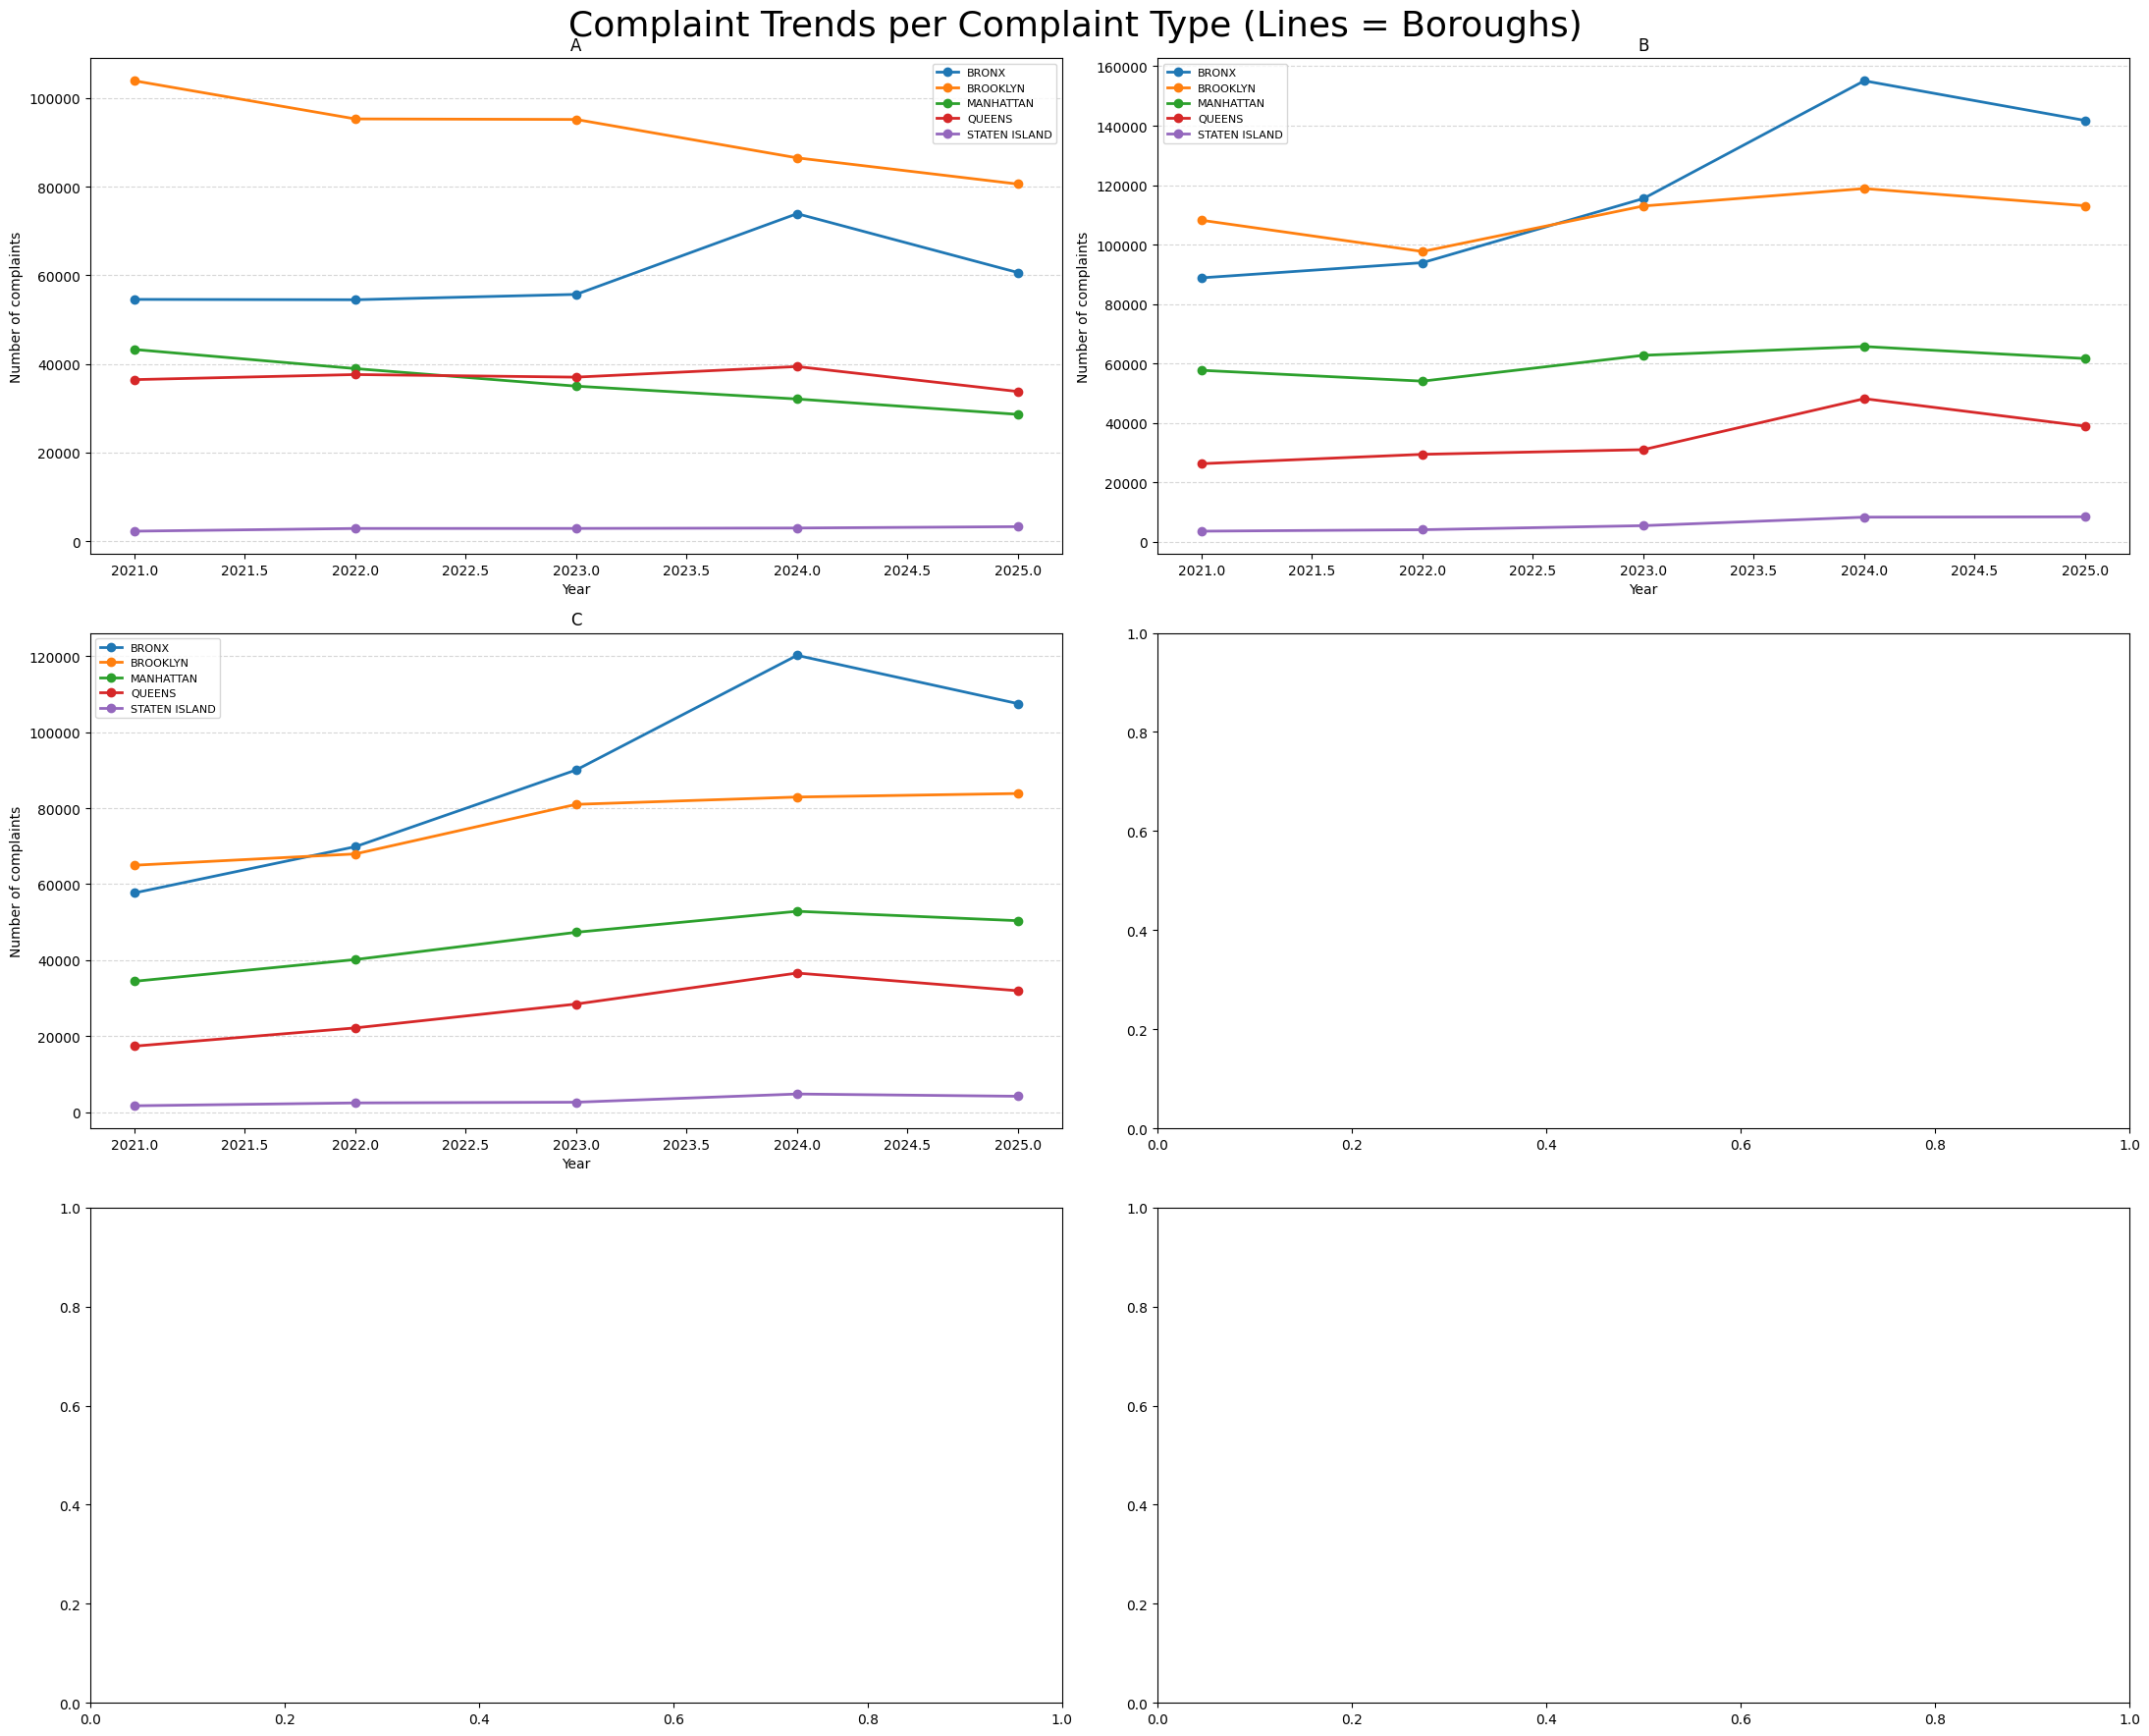

In [50]:
classes = grouped_viol["class"].unique()

fig, axes = plt.subplots(3, 2, figsize=(22, 18))  # adjust grid if needed
axes = axes.flatten()

for i, clas in enumerate(classes):
    df_c = grouped_viol[grouped_viol["class"] == clas]

    for borough in df_c["boro"].unique():
        df_b = df_c[df_c["boro"] == borough]

        axes[i].plot(
            df_b["year"],
            df_b["count"],
            marker='o',
            linewidth=2,
            label=borough
        )

    axes[i].set_title(clas)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Number of complaints")
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i].legend(fontsize=8)

plt.suptitle("Complaint Trends per Complaint Type (Lines = Boroughs)", fontsize=26)
plt.tight_layout()
plt.show()